In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import requests
import cv2

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Concatenate
from tensorflow.keras.models import Model

In [ ]:
dataset_path = "/content/drive/MyDrive/dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

num_classes = train_data.num_classes


Found 283 images belonging to 4 classes.
Found 69 images belonging to 4 classes.


In [ ]:
def enhance_image(image):
    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img = cv2.convertScaleAbs(img, alpha=1.5, beta=20)
    img = cv2.GaussianBlur(img,(3,3),0)
    return img

In [ ]:
API_KEY = "2346a1e9bd0dca2e1c97fbc80fc9d1fa"

def get_weather(lat, lon):
    url = f"http://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"

    response = requests.get(url)
    data = response.json()

    temperature = data['main']['temp']
    humidity = data['main']['humidity']

    return np.array([temperature, humidity], dtype=np.float32)

In [ ]:
lat = 18.5204   # Example: Pune
lon = 73.8567

train_weather = np.array([get_weather(lat, lon) for _ in range(train_data.samples)])
val_weather = np.array([get_weather(lat, lon) for _ in range(val_data.samples)])


In [ ]:
def combined_generator(image_gen, weather_features):
    i = 0
    n = len(weather_features)

    while True:
        images, labels = next(image_gen)
        batch_size = images.shape[0]

        if i + batch_size > n:
            i = 0

        weather_batch = weather_features[i:i + batch_size]
        i += batch_size

        yield (
            {
                "image_input": images,
                "weather_input": weather_batch
            },
            labels
        )


In [ ]:
train_dataset = tf.data.Dataset.from_generator(
    lambda: combined_generator(train_data, train_weather),
    output_signature=(
        {
            "image_input": tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32),
            "weather_input": tf.TensorSpec(shape=(None, 2), dtype=tf.float32),
        },
        tf.TensorSpec(shape=(None, num_classes), dtype=tf.float32)
    )
)

val_dataset = tf.data.Dataset.from_generator(
    lambda: combined_generator(val_data, val_weather),
    output_signature=(
        {
            "image_input": tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32),
            "weather_input": tf.TensorSpec(shape=(None, 2), dtype=tf.float32),
        },
        tf.TensorSpec(shape=(None, num_classes), dtype=tf.float32)
    )
)

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)


In [ ]:
# Image Model
base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False

image_input = Input(shape=(224,224,3), name="image_input")
x = base_model(image_input, training=False)
x = GlobalAveragePooling2D()(x)

# Weather Model
weather_input = Input(shape=(2,), name="weather_input")
y = Dense(16, activation="relu")(weather_input)

# Combine
combined = Concatenate()([x, y])
z = Dense(128, activation="relu")(combined)
z = Dense(64, activation="relu")(z)
output = Dense(num_classes, activation="softmax")(z)

model = Model(inputs=[image_input, weather_input], outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ image_input[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weather_input       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         48 │ weather_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1296)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    166,016 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │        260 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,432,564 (9.28 MB)

 Trainable params: 174,580 (681.95 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
train_steps = train_data.samples // train_data.batch_size
val_steps = val_data.samples // val_data.batch_size

history = model.fit(
    train_dataset,
    steps_per_epoch=train_steps,
    validation_data=val_dataset,
    validation_steps=val_steps,
    epochs=20
)


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 329s 39s/step - accuracy: 0.6680 - loss: 0.8475 - val_accuracy: 0.6719 - val_loss: 0.8544
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 50s 5s/step - accuracy: 0.8127 - loss: 0.4952 - val_accuracy: 0.7027 - val_loss: 0.6214
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.8327 - loss: 0.4245 - val_accuracy: 0.6216 - val_loss: 0.8337
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.8805 - loss: 0.2895 - val_accuracy: 0.6562 - val_loss: 0.7727
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.9203 - loss: 0.2188 - val_accuracy: 0.7297 - val_loss: 0.7816
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.9363 - loss: 0.1709 - val_accuracy: 0.5676 - val_loss: 0.7630
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.9522 - loss: 0.1475 - val_accuracy: 0.7031 - val_loss: 0.6161
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9841 - loss: 0.0817 - val_accuracy: 0.7297 - val_loss: 0.7786
Epoch 

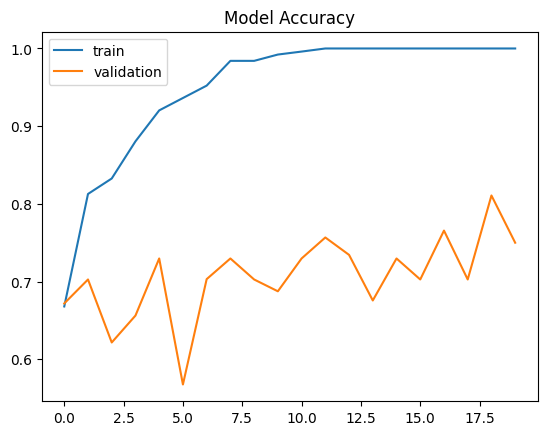

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','validation'])
plt.title("Model Accuracy")
plt.show()


In [ ]:
class_labels = list(train_data.class_indices.keys())

def recommend_solution(predicted_class, temp, humidity):

    if predicted_class == "nitrogen-N":
        if humidity < 40:
            return "Apply urea fertilizer + increase irrigation"
        else:
            return "Use compost or organic manure"

    elif predicted_class == "phosphorus-P":
        if temp < 20:
            return "Apply DAP fertilizer"
        else:
            return "Improve soil drainage"

    elif predicted_class == "potasium-K":
        return "Apply potash fertilizer + proper watering"

    elif predicted_class == "healthy":
        return "Plant is healthy 🌿"

    else:
        return "Unknown plant condition. Please consult an expert."

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path, lat, lon):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    weather = get_weather(lat, lon)
    weather = np.expand_dims(weather, axis=0)

    prediction = model.predict({
        "image_input": img_array,
        "weather_input": weather
    })

    predicted_class = class_labels[np.argmax(prediction)]

    temp, humidity = weather[0]

    recommendation = recommend_solution(predicted_class, temp, humidity)

    print("🌿 Prediction:", predicted_class)
    print("🌡 Temperature:", temp)
    print("💧 Humidity:", humidity)
    print("✅ Recommendation:", recommendation)


In [ ]:
predict_image(
    "/content/drive/MyDrive/dataset/potasium-K/K (12).jpg",
    lat=19.0760,   # Mumbai
    lon=72.8777
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
🌿 Prediction: phosphorus-P
🌡 Temperature: 33.0
💧 Humidity: 58.0
✅ Recommendation: Improve soil drainage


In [ ]:
model.save("plant_model.keras")

Prediction 

In [ ]:
!pip install tensorflow opencv-python matplotlib seaborn scikit-learn flask

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, Concatenate, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)


In [ ]:
dataset_path = "/content/drive/MyDrive/dataset"

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

num_classes = train_data.num_classes
class_labels = list(train_data.class_indices.keys())


Found 283 images belonging to 4 classes.
Found 69 images belonging to 4 classes.


In [ ]:
API_KEY = "2346a1e9bd0dca2e1c97fbc80fc9d1fa"

def get_weather(lat, lon):
    url = f"http://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"
    data = requests.get(url).json()

    temp = data['main']['temp']
    humidity = data['main']['humidity']

    return np.array([temp, humidity], dtype=np.float32)


In [ ]:
lat, lon = 18.5204, 73.8567  # Pune

train_weather = np.array([get_weather(lat, lon) for _ in range(train_data.samples)])
val_weather = np.array([get_weather(lat, lon) for _ in range(val_data.samples)])


In [ ]:
def combined_generator(image_gen, weather):
    i = 0
    while True:
        images, labels = next(image_gen)
        batch = images.shape[0]
        weather_batch = weather[i:i+batch]
        i = (i + batch) % len(weather)

        yield ({"image_input": images, "weather_input": weather_batch}, labels)


In [ ]:
train_dataset = tf.data.Dataset.from_generator(
    lambda: combined_generator(train_data, train_weather),
    output_signature=(
        {
            "image_input": tf.TensorSpec(shape=(None,224,224,3), dtype=tf.float32),
            "weather_input": tf.TensorSpec(shape=(None,2), dtype=tf.float32)
        },
        tf.TensorSpec(shape=(None,num_classes), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_generator(
    lambda: combined_generator(val_data, val_weather),
    output_signature=(
        {
            "image_input": tf.TensorSpec(shape=(None,224,224,3), dtype=tf.float32),
            "weather_input": tf.TensorSpec(shape=(None,2), dtype=tf.float32)
        },
        tf.TensorSpec(shape=(None,num_classes), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)


In [ ]:
base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')

for layer in base_model.layers:
    layer.trainable = False

# Image branch
image_input = Input(shape=(224,224,3), name="image_input") # Explicitly name the image input
x = base_model(image_input, training=False) # Pass the named input to the base model
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

# Weather branch
weather_input = Input(shape=(2,), name="weather_input")
y = Dense(32, activation='relu')(weather_input)

# Combine
combined = Concatenate()([x, y])
z = Dense(128, activation='relu')(combined)
z = Dropout(0.3)(z)
output = Dense(num_classes, activation='softmax')(z)

model = Model(inputs=[image_input, weather_input], outputs=output)

model.compile(optimizer=tf.keras.optimizers.Adam(0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3)
]

history = model.fit(
    train_dataset,
    steps_per_epoch=train_data.samples//32,
    validation_data=val_dataset,
    validation_steps=val_data.samples//32,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.5859 - loss: 1.7193 - val_accuracy: 0.6216 - val_loss: 0.9850 - learning_rate: 1.0000e-05
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.5179 - loss: 1.8606 - val_accuracy: 0.6216 - val_loss: 1.0474 - learning_rate: 1.0000e-05
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.6215 - loss: 1.6208 - val_accuracy: 0.6719 - val_loss: 0.7760 - learning_rate: 1.0000e-05
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.5817 - loss: 1.5632 - val_accuracy: 0.7027 - val_loss: 0.8405 - learning_rate: 1.0000e-05
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step - accuracy: 0.5896 - loss: 1.5870 - val_accuracy: 0.7027 - val_loss: 0.7861 - learning_rate: 1.0000e-05
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step - accuracy: 0.5857 - loss: 1.7203 - val_accuracy: 0.6719 - val_loss: 0.8161 - learning_rate: 1.0000e-05
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.5578 - loss: 1.7352 - val_

In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_dataset, steps_per_epoch=train_data.samples // 32, epochs=10)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 77s 4s/step - accuracy: 0.7888 - loss: 0.7180
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.8088 - loss: 0.6696
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.8477 - loss: 0.4811
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.8287 - loss: 0.5871
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.8406 - loss: 0.5634
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.8207 - loss: 0.5293
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.8167 - loss: 0.5253
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.8207 - loss: 0.5782
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.8566 - loss: 0.4423
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.8367 - loss: 0.5950


3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step


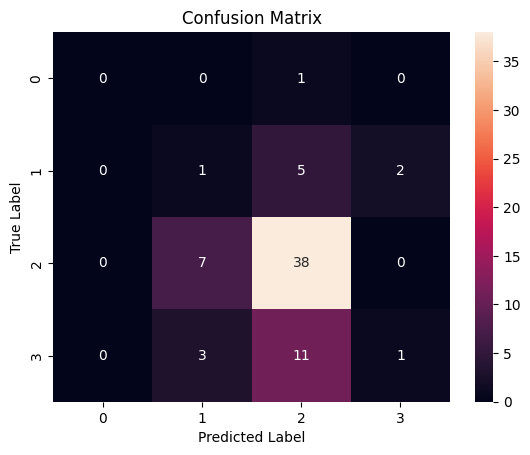

              precision    recall  f1-score   support

     healthy       0.00      0.00      0.00         1
  nitrogen-N       0.09      0.12      0.11         8
phosphorus-P       0.69      0.84      0.76        45
  potasium-K       0.33      0.07      0.11        15

    accuracy                           0.58        69
   macro avg       0.28      0.26      0.24        69
weighted avg       0.53      0.58      0.53        69



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y_pred = model.predict(val_dataset, steps=len(val_data))
y_pred_classes = np.argmax(y_pred, axis=1)

# To get true labels for the confusion matrix, we need to iterate through val_data once
# and collect the labels. Note: val_data shuffles, so ensure consistency if this is critical.
# For simpler cases, you might re-initialize val_data or collect all labels upfront.
# Assuming val_data.classes is ordered consistently with val_dataset iteration here.

# Get true labels from the val_data generator for evaluation
# Note: This iterates through the generator. For consistent comparison with y_pred
# which processes the entire dataset, you might need to ensure val_dataset
# provides data in the same order if it's not already deterministic.
# A common approach is to get all true labels at once if feasible.
val_true_labels = []
for i in range(len(val_data)):
    _, labels = val_data[i]
    val_true_labels.extend(np.argmax(labels, axis=1))

cm = confusion_matrix(val_true_labels, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print(classification_report(val_true_labels, y_pred_classes, target_names=class_labels))


In [ ]:
def grad_cam(model, inputs_dict, layer_name="mobilenetv2_1.00_224"):
    # 1. Access the target layer. In our model, 'mobilenetv2_1.00_224' is the base_model layer
    base_model = model.get_layer(layer_name)
    # We target the last conv layer of MobileNetV2 specifically for better heatmaps
    last_conv_layer = base_model.get_layer("out_relu")

    # 2. Create a model that maps the image input to the activations of the last conv layer
    # Since the base_model is a layer inside 'model', we use its internal structure
    intermediate_model = Model(base_model.input, last_conv_layer.output)

    # 3. Create the Gradient Tape
    with tf.GradientTape() as tape:
        # Get the convolutional outputs for the image input
        img_input = inputs_dict["image_input"]
        conv_outputs = intermediate_model(img_input)

        # Get the final predictions from the main model
        # We need to watch the conv_outputs to compute gradients later
        tape.watch(conv_outputs)

        # To get the gradients through the rest of the model, we simulate the forward pass
        # of the layers following the base_model
        x = model.get_layer("global_average_pooling2d_1")(conv_outputs)
        x = model.get_layer("batch_normalization")(x)
        x = model.get_layer("dense_4")(x)
        x = model.get_layer("dropout_2")(x)

        # Weather branch
        y = model.get_layer("dense_5")(inputs_dict["weather_input"])

        # Concatenate and final layers
        combined = model.get_layer("concatenate_1")([x, y])
        z = model.get_layer("dense_6")(combined)
        z = model.get_layer("dropout_3")(z)
        predictions = model.get_layer("dense_7")(z)

        class_idx = np.argmax(predictions[0])
        loss = predictions[:, class_idx]

    # 4. Extract gradients
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Generate Heatmap
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) > 0:
        heatmap /= np.max(heatmap)

    return heatmap

In [ ]:
def recommend_solution(predicted_class, temp, humidity):

    recommendations = []

    # 🔶 1. Nitrogen Deficiency
    if predicted_class == "Nitrogen":
        recommendations.append("Apply Nitrogen-rich fertilizers like Urea or Ammonium Sulfate.")
        recommendations.append("Use organic compost or green manure to improve soil fertility.")
        recommendations.append("Avoid over-irrigation as it can leach nitrogen from soil.")

        if humidity < 40:
            recommendations.append("Low humidity detected → Increase irrigation frequency to maintain moisture.")

        if temp > 35:
            recommendations.append("High temperature → Apply fertilizer during early morning or evening to prevent loss.")

    # 🔶 2. Phosphorus Deficiency
    elif predicted_class == "Phosphorus":
        recommendations.append("Apply DAP (Di-Ammonium Phosphate) or Bone Meal.")
        recommendations.append("Maintain soil pH between 6.0–7.0 for better phosphorus absorption.")
        recommendations.append("Improve soil aeration and drainage.")

        if temp < 20:
            recommendations.append("Low temperature → Phosphorus uptake is slow, consider foliar spray.")

        if humidity > 70:
            recommendations.append("High humidity → Avoid waterlogging, ensure proper drainage.")

    # 🔶 3. Potassium Deficiency
    elif predicted_class == "Potassium":
        recommendations.append("Apply Potash fertilizers like MOP (Muriate of Potash).")
        recommendations.append("Use wood ash as a natural potassium source.")
        recommendations.append("Maintain proper watering schedule.")

        if temp > 35:
            recommendations.append("High temperature → Increase irrigation to reduce plant stress.")

        if humidity < 30:
            recommendations.append("Very low humidity → Risk of drought stress, mulch soil to retain moisture.")

    # 🔶 4. Healthy Plant
    else:
        recommendations.append("Plant is healthy 🌿 Maintain current practices.")
        recommendations.append("Use balanced fertilizers (NPK) periodically.")
        recommendations.append("Monitor weather conditions regularly.")

        if temp > 38:
            recommendations.append("Extreme heat → Provide shade or increase watering.")

        if humidity > 80:
            recommendations.append("High humidity → Risk of fungal diseases, ensure airflow.")

    # 🔥 GENERAL WEATHER-BASED RULES (APPLIED TO ALL)

    if temp > 40:
        recommendations.append("⚠ Extreme heat → Avoid fertilizer spraying during daytime.")

    if humidity < 25:
        recommendations.append("⚠ Very low humidity → Immediate irrigation required.")

    if humidity > 85:
        recommendations.append("⚠ Very high humidity → Apply fungicide to prevent disease.")

    return "\n".join(recommendations)


In [ ]:
from tensorflow.keras.preprocessing import image

def predict(img_path, lat, lon):

    img = image.load_img(img_path, target_size=(224,224))
    img = image.img_to_array(img)/255.0
    img = np.expand_dims(img, axis=0)

    weather = get_weather(lat, lon)
    weather = np.expand_dims(weather, axis=0)

    pred = model.predict({"image_input": img, "weather_input": weather})
    pred_class = class_labels[np.argmax(pred)]

    temp, humidity = weather[0]

    rec = recommend_solution(pred_class, temp, humidity)

    print("Prediction:", pred_class)
    print("Temp:", temp)
    print("Humidity:", humidity)
    print("Recommendation:\n", rec)


In [ ]:
predict(
    "/content/drive/MyDrive/dataset/potasium-K/K (12).jpg",
    lat=19.0760,   # Mumbai
    lon=72.8777
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediction: phosphorus-P
Temp: 29.0
Humidity: 74.0
Recommendation:
 Plant is healthy 🌿 Maintain current practices.
Use balanced fertilizers (NPK) periodically.
Monitor weather conditions regularly.


In [ ]:
from tensorflow.keras.preprocessing import image
import matplotlib.cm as cm

img_path = "/content/drive/MyDrive/dataset/potasium-K/K (12).jpg"

# Load and preprocess the image for prediction
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
original_img = img_array.copy()
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Get weather data
lat = 19.0760
lon = 72.8777
weather_input_for_gradcam = get_weather(lat, lon)
weather_input_for_gradcam = np.expand_dims(weather_input_for_gradcam, axis=0)

# Prepare inputs for Grad-CAM function
inputs_for_gradcam = {
    "image_input": img_array,
    "weather_input": weather_input_for_gradcam
}

# Get Grad-CAM heatmap
heatmap = grad_cam(model, inputs_for_gradcam, layer_name="mobilenetv2_1.00_224")

# Rescale heatmap to original image size
heatmap = cv2.resize(heatmap.numpy(), (original_img.shape[1], original_img.shape[0]))
heatmap = np.uint8(255 * heatmap)

# Apply colormap to heatmap
colored_heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Superimpose heatmap on original image
superimposed_img = cv2.addWeighted(original_img.astype(np.uint8), 0.6, colored_heatmap, 0.4, 0)

# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_img.astype(np.uint8))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title("Grad-CAM Heatmap")
plt.axis('off')
plt.show()

ValueError: No such layer: batch_normalization. Existing layers are: ['image_input', 'mobilenetv2_1.00_224', 'global_average_pooling2d_1', 'batch_normalization_1', 'dense_4', 'weather_input', 'dropout_2', 'dense_5', 'concatenate_1', 'dense_6', 'dropout_3', 'dense_7'].